In [198]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
import ipywidgets as widgets
from ipywidgets import interact
import glob
import os
from skimage.measure import ransac
import ipywidgets as widgets
from IPython.display import display
from kneed import KneeLocator
from sklearn.neighbors import NearestNeighbors
# Set up matplotlib for interactive plotting in Jupyter
%matplotlib widget

In [ ]:
col_labels = ['A', 'B', 'C', 'D', 'E']
row_labels = ['1', '2', '3', '4', '5']

select_dimple = 'C5'  # Define the target dimple

# --- DEFINE YOUR FOLDER PATH HERE ---
folder_path = '/mnt/d/RADICAL_data/High_temp_15_July/C5/Displacement_XYZ'
LoadData = True  # Set to True to load data for the first time, False to skip loading for subsequent runs
# play with DBSCAN parameters (eps, min_samples) to remove outliers and get the desired ROI

In [200]:
# --- 1. Define a Custom PlaneModel for RANSAC ---
# scikit-image's ransac requires a model class with .estimate() and .residuals() methods.
class PlaneModel:
    def __init__(self):
        self.params = None

    def estimate(self, data):
        """
        Estimates the plane model from a minimal sample of 3 points.
        
        The plane is defined by a point (the centroid) and a normal vector.
        """
        # The plane is defined by a point (the centroid) and a normal vector.
        # Find the centroid
        centroid = np.mean(data, axis=0)
        
        # Use SVD to find the normal vector of the plane
        _, _, vh = np.linalg.svd(data - centroid)
        normal = vh[2] # The last singular vector is the normal
        
        self.params = (centroid, normal)
        return True

    def residuals(self, data):
        """
        Calculates the perpendicular distance of each point to the estimated plane.
        """
        if self.params is None:
            raise RuntimeError("Model has not been estimated yet.")
            
        centroid, normal = self.params
        # The distance is the absolute value of the dot product of the vector 
        # from the centroid to the point, with the normal vector.
        return np.abs(np.dot(data - centroid, normal))

In [201]:
import numpy as np
import glob
import os

if LoadData:
    # --- DEFINE YOUR FOLDER PATH HERE ---
    # Replace 'YOUR/FOLDER/PATH' with the actual path to your data files.
    # folder_path = '/mnt/d/RADICAL_data/High_temp_15_July/C3/Displacement_XYZ'

    # Create the full search pattern by joining the path and filename pattern
    search_pattern = os.path.join(folder_path, 'DICe_solution_*.txt')

    # Find all data files using the new pattern and sort them
    fnames = sorted(glob.glob(search_pattern))
    num_frames = len(fnames)

    # Check if any files were found
    if not fnames:
        print(f"Error: No files found at the specified path: {search_pattern}")
    else:
        # Load each file into a list of numpy arrays
        data = []
        for i, filename in enumerate(fnames):
            # Use delimiter=',' for comma-separated files and skiprows=1 to ignore the header.
            currStep = np.loadtxt(filename, delimiter=',', skiprows=1)
            data.append(currStep)
            print(f'Step {i} completed')

        print(f"\nSuccessfully loaded {num_frames} data files.")

Step 0 completed
Step 1 completed
Step 2 completed
Step 3 completed
Step 4 completed
Step 5 completed
Step 6 completed
Step 7 completed
Step 8 completed
Step 9 completed
Step 10 completed
Step 11 completed
Step 12 completed
Step 13 completed
Step 14 completed
Step 15 completed
Step 16 completed
Step 17 completed
Step 18 completed
Step 19 completed
Step 20 completed
Step 21 completed
Step 22 completed
Step 23 completed
Step 24 completed
Step 25 completed
Step 26 completed
Step 27 completed
Step 28 completed
Step 29 completed
Step 30 completed
Step 31 completed
Step 32 completed
Step 33 completed
Step 34 completed
Step 35 completed
Step 36 completed
Step 37 completed
Step 38 completed
Step 39 completed
Step 40 completed
Step 41 completed
Step 42 completed
Step 43 completed
Step 44 completed
Step 45 completed
Step 46 completed
Step 47 completed
Step 48 completed
Step 49 completed
Step 50 completed
Step 51 completed
Step 52 completed
Step 53 completed
Step 54 completed
Step 55 completed
St

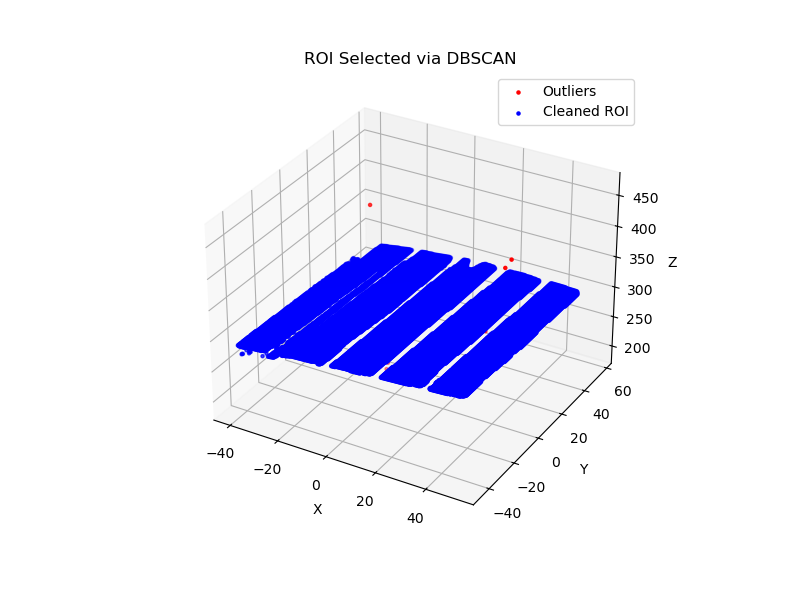

In [212]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# Assume 'data' is loaded from your previous steps
# Get data from the last step (frame)
step_data_last = data[0]
new_coords = step_data_last[:, 8:11] # NEW_COORDINATES_X, Y, Z

# --- Implement DBSCAN to find the main cluster ---
# Note: You may need to tune 'eps' and 'min_samples' for your specific data.
# 'eps' is the max distance between points to be considered neighbors.
# 'min_samples' is the number of neighbors a point needs to be a core point.
db_global = DBSCAN(eps=5, min_samples=10).fit(new_coords)

# Create a boolean mask for the core and border points (non-outliers)
# DBSCAN labels outliers as -1.
is_inlier_global = db_global.labels_ != -1

# Filter the original coordinates to get the cleaned Region of Interest (ROI)
roi_coords = new_coords[is_inlier_global]
outliers = new_coords[~is_inlier_global]


# --- Visualize the results ---
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot outliers in red
ax.scatter(outliers[:, 0], outliers[:, 1], outliers[:, 2], s=5, c='red', label='Outliers')
# Plot the main cluster (ROI) in blue
ax.scatter(roi_coords[:, 0], roi_coords[:, 1], roi_coords[:, 2], s=5, c='blue', label='Cleaned ROI')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('ROI Selected via DBSCAN')
ax.legend()
plt.show()



Rotation Matrix R:
[[ 0.95791305  0.0077747   0.28695321]
 [ 0.0077747   0.99856378 -0.05300874]
 [-0.28695321  0.05300874  0.95647683]]


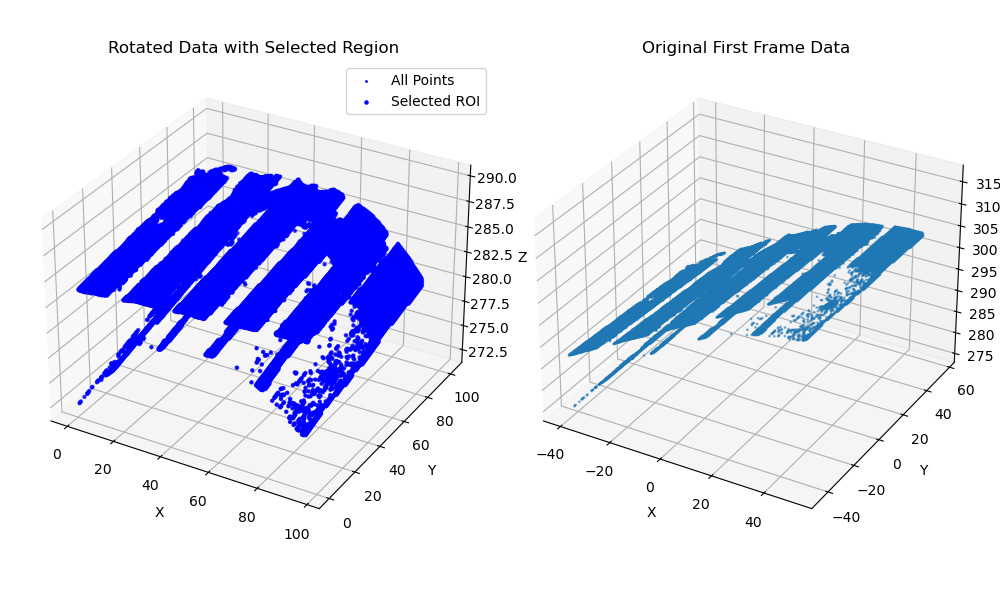

In [203]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import glob
import os

# --- Configuration ---
def get_rotation_from_plane(points):
    """
    Calculates a rotation matrix to align a plane-fitted point cloud with the XY plane.
    
    Args:
        points (np.ndarray): An (N, 3) array of 3D points.
        
    Returns:
        np.ndarray: A (3, 3) rotation matrix.
    """
    # 1. Fit a plane using PCA to find the normal vector
    pca = PCA(n_components=3)
    pca.fit(points)
    # The normal vector is the component with the smallest variance (the 3rd one)
    normal_vector = pca.components_[2]

    # 2. Ensure consistent normal vector orientation (same as MATLAB code)
    if normal_vector[0] > 0:
        normal_vector = -normal_vector
        
    # 3. Define the target normal (Z-axis for the XY plane)
    target_normal = np.array([0, 0, 1])

    # 4. Compute rotation axis and angle
    rotation_axis = np.cross(normal_vector, target_normal)
    rotation_axis /= np.linalg.norm(rotation_axis)
    
    cos_theta = np.dot(normal_vector, target_normal)
    theta = np.arccos(cos_theta)

    # 5. Create rotation matrix using Rodrigues' formula
    K = np.array([[0, -rotation_axis[2], rotation_axis[1]],
                  [rotation_axis[2], 0, -rotation_axis[0]],
                  [-rotation_axis[1], rotation_axis[0], 0]])
    
    R = np.eye(3) + np.sin(theta) * K + (1 - np.cos(theta)) * (K @ K)
    
    return R

# --- Main Execution ---

    
# 2. Get the points for plane fitting and rotation
points_to_rotate = roi_coords

# 3. Calculate the rotation matrix and apply it
R = get_rotation_from_plane(points_to_rotate)
# Use the @ operator for matrix multiplication
rotated_points = (R @ points_to_rotate.T).T

rotated_points[:,0]= rotated_points[:,0] -np.min(rotated_points[:,0]) 
rotated_points[:,1]= rotated_points[:,1] -np.min(rotated_points[:,1]) 

print("\nRotation Matrix R:")
print(R)
# 4. Select a region of interest from the ROTATED data
# These values define a bounding box; you may need to adjust them.

roi_points = rotated_points

# 5. Visualize the results
fig = plt.figure(figsize=(10, 6))

# Plot 1: Original Data
ax1 = fig.add_subplot(1, 2, 2, projection='3d')
ax1.scatter(points_to_rotate[:,0], points_to_rotate[:,1], points_to_rotate[:,2], s=1, alpha=0.5)
ax1.set_title("Original First Frame Data")
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')

# Plot 2: Rotated Data with ROI
ax2 = fig.add_subplot(1, 2, 1, projection='3d')
# Plot all rotated points in grey
ax2.scatter(rotated_points[:,0], rotated_points[:,1], rotated_points[:,2], s=1, c='blue', label='All Points')
# Plot the selected ROI points in blue
ax2.scatter(roi_points[:,0], roi_points[:,1], roi_points[:,2], s=5, c='blue', label='Selected ROI')
ax2.set_title("Rotated Data with Selected Region")
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
ax2.legend()

plt.tight_layout()
plt.show()

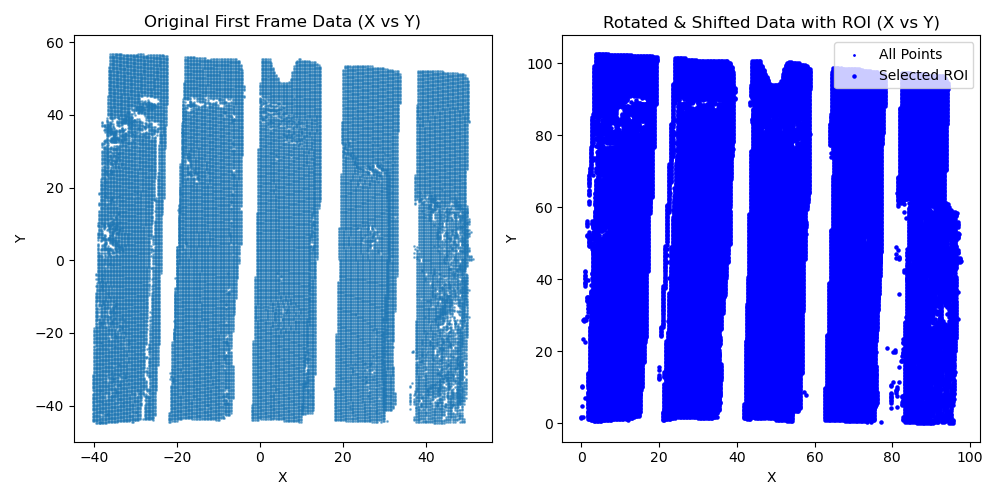

In [204]:
# Visualize the results in 2D
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Plot 1: Original Data (X vs Y)
axs[0].scatter(points_to_rotate[:, 0], points_to_rotate[:, 1], s=1, alpha=0.5)
axs[0].set_title("Original First Frame Data (X vs Y)")
axs[0].set_xlabel('X'); axs[0].set_ylabel('Y')
# axs[0].set_aspect('equal', adjustabl  e='box')

# Plot 2: Rotated & Shifted Data with ROI (X vs Y)
axs[1].scatter(rotated_points[:, 0], rotated_points[:, 1], s=1, c='blue', label='All Points')
axs[1].scatter(roi_points[:, 0], roi_points[:, 1], s=5, c='blue', label='Selected ROI')
axs[1].set_title("Rotated & Shifted Data with ROI (X vs Y)")
axs[1].set_xlabel('X'); axs[1].set_ylabel('Y')
axs[1].legend()
# axs[1].set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

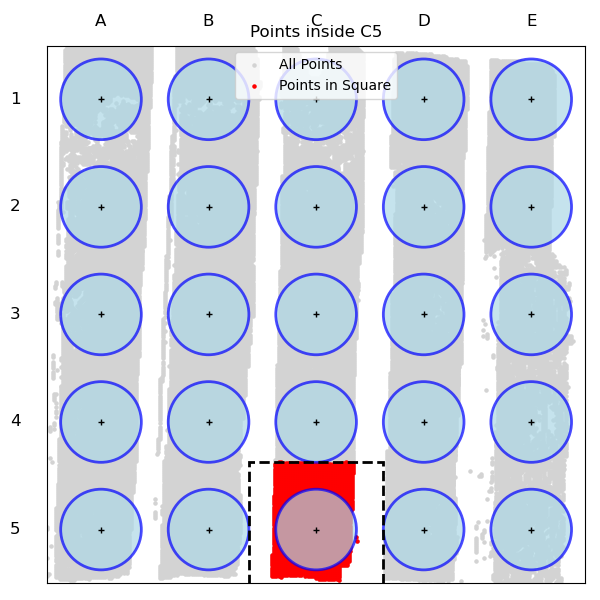

Found 2076 points inside the square.


In [205]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
dimple_diameter = 15  # mm
dimple_radius = dimple_diameter / 2
spacing = 20  # mm
square_side = spacing/2 + 2 * dimple_radius  # 35 mm
half_side = square_side / 2

# Positions and labels
positions = np.arange(0, 100, spacing) + 10  # [10, 30, 50, 70, 90]
X, Y = np.meshgrid(positions, positions)
centers = np.vstack([X.ravel(), Y.ravel()]).T

row_labels = ['1', '2', '3', '4', '5']
col_labels = ['A', 'B', 'C', 'D', 'E']

# select_dimple = 'C3`'  # Define the target dimple
# Define the target cell directly
cell_to_highlight =select_dimple# 'C3'

transformed_points = rotated_points

# Automatically find coordinates for the target cell
col_char = cell_to_highlight[0]
row_char = cell_to_highlight[1:]
col_idx = col_labels.index(col_char)
row_label_idx = row_labels.index(row_char)
row_pos_idx = len(row_labels) - 1 - row_label_idx
x_center = positions[col_idx]
y_center = positions[row_pos_idx]

# Compute bottom-left corner of the square and draw it
square_x = x_center - half_side
square_y = y_center - half_side
square = plt.Rectangle((square_x, square_y), square_side, square_side,
                       edgecolor='black', facecolor='none', lw=2, linestyle='--')
ax.add_patch(square)


mask = (
    (transformed_points[:, 0] >= square_x) &
    (transformed_points[:, 0] <= square_x + square_side) &
    (transformed_points[:, 1] >= square_y) &
    (transformed_points[:, 1] <= square_y + square_side)
)

# Apply the mask to get the points for further processing
points_inside_square = transformed_points[mask]

# --- 4. Plotting and Visualization ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')

# Plot all points in a light color
ax.scatter(transformed_points[:, 0], transformed_points[:, 1], s=5, c='lightgray', label='All Points')
# Plot the selected points in a prominent color
ax.scatter(points_inside_square[:, 0], points_inside_square[:, 1], s=5, c='red', label='Points in Square')

# Draw circles and their centers
for i, (x, y) in enumerate(centers):
    circle = plt.Circle((x, y), dimple_radius, edgecolor='blue', facecolor='lightblue', lw=2, alpha=0.7)
    ax.add_patch(circle)
    ax.plot(x, y, 'k+', markersize=5)

# Draw the selection square
square = plt.Rectangle((square_x, square_y), square_side, square_side,
                       edgecolor='black', facecolor='none', lw=2, linestyle='--')
ax.add_patch(square)

# Add labels
for i in range(5):
    ax.text(positions[i], 100 + 3, col_labels[i], ha='center', va='bottom', fontsize=12)
    ax.text(-5, positions[4 - i], row_labels[i], ha='right', va='center', fontsize=12)

# Final settings
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f"Points inside {cell_to_highlight}")
plt.grid(True, linestyle='--', linewidth=0.5)
ax.legend()
plt.tight_layout()
plt.show()

# You can now use 'points_inside_square' for further processing
print(f"Found {len(points_inside_square)} points inside the square.")


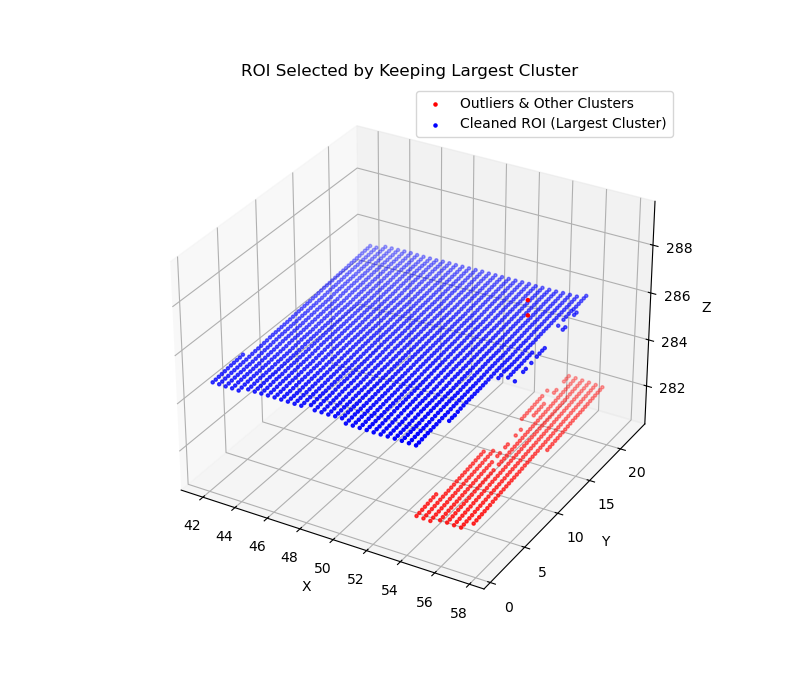

In [206]:
# --- Implement DBSCAN to find the main cluster ---
# Note: You may need to tune 'eps' and 'min_samples' for your specific data.
# 'eps' is the max distance between points to be considered neighbors.
# 'min_samples' is the number of neighbors a point needs to be a core point.
points_inside_square = rotated_points[mask]
new_coords =points_inside_square
# --- 1. Find optimal eps and run DBSCAN  ---
min_samples = 10
k = min_samples
nbrs = NearestNeighbors(n_neighbors=k).fit(new_coords)
distances, _ = nbrs.kneighbors(new_coords)
k_distances = np.sort(distances[:, k-1])
knee = KneeLocator(range(1, len(k_distances)+1), k_distances, S=10.0, curve="convex", direction="increasing")
optimal_eps = knee.elbow_y if knee.elbow_y else 1.0 # Fallback eps

db = DBSCAN(eps=optimal_eps, min_samples=min_samples).fit(new_coords)
labels = db.labels_


# --- 2. Post-Process DBSCAN Results to Find the Largest Cluster ---
# Find all unique cluster labels. The label -1 is for noise.
# --- 2. Post-Process DBSCAN Results to Find the Largest Cluster ---
# Get the labels from the DBSCAN result
labels = db.labels_

# Find all unique cluster labels. The label -1 is for noise.
unique_labels_set = set(labels)
if -1 in unique_labels_set:
    unique_labels_set.remove(-1)

# Convert the set of labels to a list to allow indexing
unique_labels = list(unique_labels_set)

# Find the label of the largest cluster
if len(unique_labels) > 0:
    # Count points in each cluster by iterating through the list
    cluster_sizes = [np.sum(labels == label) for label in unique_labels]
    
    # Find the list index of the largest cluster
    largest_cluster_idx = np.argmax(cluster_sizes)
    
    # Get the corresponding label from the list using the index
    largest_cluster_label = unique_labels[largest_cluster_idx]

    # Create a final mask to select only the largest cluster
    is_in_largest_cluster = (labels == largest_cluster_label)
else:
    # Handle case where no clusters were found
    is_in_largest_cluster = np.zeros_like(labels, dtype=bool)

# The final ROI is the largest cluster. Everything else is an outlier.
final_roi_coords = new_coords[is_in_largest_cluster]
outliers = new_coords[~is_in_largest_cluster]


# --- 3. Visualize the final results ---
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')
# Plot outliers (includes noise AND smaller clusters)
ax.scatter(outliers[:, 0], outliers[:, 1], outliers[:, 2], s=5, c='red', label='Outliers & Other Clusters')
# Plot the main cluster (ROI)
ax.scatter(final_roi_coords[:, 0], final_roi_coords[:, 1], final_roi_coords[:, 2], s=5, c='blue', label='Cleaned ROI (Largest Cluster)')
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('ROI Selected by Keeping Largest Cluster')
ax.legend()
plt.show()


In [207]:
print(db_global.labels_.shape)
print(mask.shape)
print(db.labels_.shape)
L1_mask = is_in_largest_cluster #np.where(db.labels_ != -1, True, False)
L2_mask = mask.copy() 
L3_mask = np.where(db_global.labels_ != -1, True, False)

# get global mask 
L2_mask[L2_mask] = L1_mask
L3_mask[L3_mask] = L2_mask

final_mask = L3_mask
print(final_mask.shape)



(46617,)
(46596,)
(2076,)
(46617,)


In [208]:
# Initialize lists to store the processed data for each frame
X_def_all = []
X_corr_all = []
X0_all = [] # Will store initial coordinates for color mapping
ind = np.where(final_mask)[0]  # Indices of points in the final mask
# --- Main processing loop for each frame ---
for i in range(num_frames):
    stepData = data[i]
    
    # Get initial coordinates (MODEL_COORDINATES) and displacements for the ROI
    # Indices 2,3,4 -> MODEL_COORDINATES_X,Y,Z
    # Indices 5,6,7 -> MODEL_DISPLACEMENT_X,Y,Z
    X0 = stepData[ind, 2:5]
    U_frame = stepData[ind, 5:8]
    
    # 1. Calculate deformed coordinates
    X_def = X0 + U_frame

    # 2. Kabsch Algorithm to remove rigid body motion
    X0_mean = np.mean(X0, axis=0)
    X_def_mean = np.mean(X_def, axis=0)
    H = (X0 - X0_mean).T @ (X_def - X_def_mean)
    U_k, s, Vt_k = np.linalg.svd(H)
    R_kabsch = Vt_k.T @ U_k.T
    
    # Ensure a proper rotation matrix (determinant > 0)
    if np.linalg.det(R_kabsch) < 0:
        Vt_k[2, :] *= -1
        R_kabsch = Vt_k.T @ U_k.T
        
    t = X_def_mean - (R_kabsch @ X0_mean)
    
    X_rigid = (R_kabsch @ X0.T).T + t
    U_rigid_removed = X_def - X_rigid
    
    # 3. First PCA to establish a local coordinate system
    pca1 = PCA(n_components=3)
    X0_centered = X0 - np.mean(X0, axis=0)
    pca1.fit(X0_centered)
    R_global_to_local = pca1.components_
    
    U_local = (R_global_to_local @ U_rigid_removed.T).T
    X_local_initial = (R_global_to_local @ X0.T).T
    
    # 4. Second PCA for fine-tuning alignment (based on a "base" region)
    xu = np.column_stack([X_local_initial[:, 0], X_local_initial[:, 1], U_local[:, 2]])
    
    # Select base indices using the same logic 
    # Fit a plane model using our custom class
    # 'residual_threshold' is the max distance a point can be from the plane to be an inlier.
    model_robust, is_base_mask = ransac(xu, PlaneModel, min_samples=3,
                                    residual_threshold=0.1, max_trials=100)

    # Separate the points using the mask returned by RANSAC
    base_points = xu[is_base_mask]
    deformed_points = xu[~is_base_mask]
    base_indices =is_base_mask
    # # Note: X0 uses original global coordinates
    # base_indices = X0[:, 0] > 15 
    
    # Avoid errors if no points match the criteria
    if np.any(base_indices):
        xu_base_mean = np.mean(xu[base_indices], axis=0)
        
        pca2 = PCA(n_components=3)
        xu_centered_base = xu[base_indices] - xu_base_mean
        pca2.fit(xu_centered_base)
        R_to_local = pca2.components_

        # Apply this refined rotation to all points
        U_centered = U_local - np.mean(U_local[base_indices], axis=0)
        X_centered2 = xu - xu_base_mean
        
        X_corr = (R_to_local @ X_centered2.T).T
        U_local_final = (R_to_local @ U_centered.T).T # Not used in plot
    else: # Fallback if no base points are found
        X_corr = xu

    # Store results for plotting
    X_def_all.append(X_def)
    X_corr_all.append(X_corr)
    X0_all.append(X0) # Storing for color data

print("\nData processing complete.")


Data processing complete.


Output()

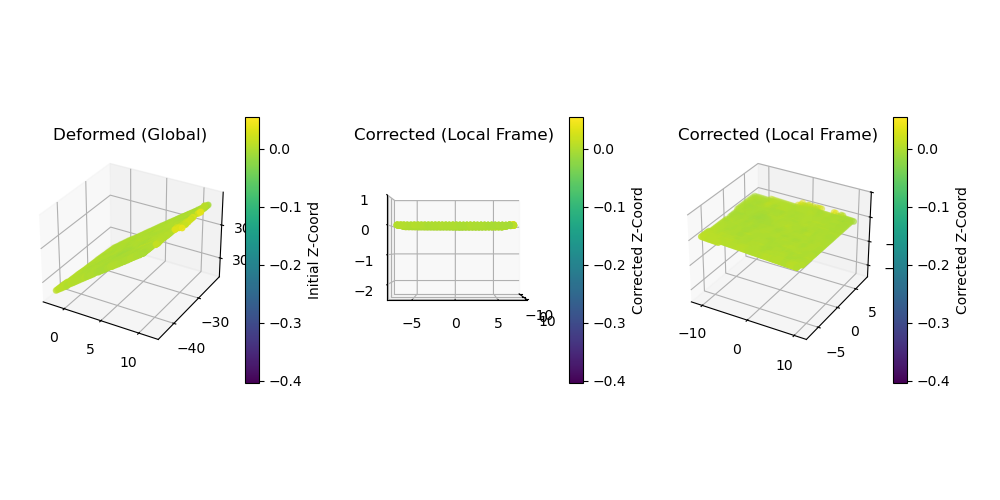

In [209]:

# --- Create the figure and subplots ---
fig = plt.figure(figsize=(10, 5)) # Increased figure width for color bars
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax3 = fig.add_subplot(1, 3, 3, projection='3d')

# --- Initial scatter plots with the first frame's data ---
color_data = X_corr_all[-1][:, 2] # Color by initial Z-coordinate
h1 = ax1.scatter(X_def_all[0][:, 0], X_def_all[0][:, 1], X_def_all[0][:, 2], c=color_data, s=15, cmap='viridis')
h2 = ax2.scatter(X_corr_all[0][:, 0], X_corr_all[0][:, 1], X_corr_all[0][:, 2], c=X_corr_all[-1][:, 2], s=15, cmap='viridis')
h3 = ax3.scatter(X_corr_all[0][:, 0], X_corr_all[0][:, 1], X_corr_all[0][:, 2], c=X_corr_all[-1][:, 2], s=15, cmap='viridis')
# --- ADD COLORBARS ---
# Add a color bar for each subplot, attached to the correct axes.
# The 'shrink' parameter makes the color bar smaller than the plot height.
fig.colorbar(h1, ax=ax1, shrink=0.6, label='Initial Z-Coord')
fig.colorbar(h2, ax=ax2, shrink=0.6, label='Corrected Z-Coord')
fig.colorbar(h3, ax=ax3, shrink=0.6, label='Corrected Z-Coord')


# --- Set plot titles and initial views ---
ax1.set_title('Deformed (Global)')
ax2.set_title('Corrected (Local Frame)')
ax3.set_title('Corrected (Local Frame)')

ax2.view_init(elev=0, azim=0) # view([0,0])
ax3.view_init(elev=30, azim=-60) # Default 3D view

# ax1.set_aspect('equal')
# ax2.set_aspect('equal')
# ax3.set_aspect('equal')

ax2.set_zlim(-2.5, 1)
ax3.set_zlim(-2.5, 1)
fig.tight_layout(pad=2.0) # Adjust padding


# --- Function to update plots (no changes needed here) ---
def update_frame(frame):
    X_def = X_def_all[frame]
    X_corr = X_corr_all[frame]
    X_corr_0 = X_corr_all[-1]  # Use the last frame for x-y coordinates
    color_data = X_corr_all[frame][:, 2]

    # Update plot data
    h1._offsets3d = (X_def[:, 0], X_def[:, 1], X_def[:, 2])
    h1.set_array(color_data)
    
    h2._offsets3d = (X_corr_0[:, 0], X_corr_0[:, 1], X_corr[:, 2])
    h2.set_array(X_corr[:, 2])
    
    h3._offsets3d = (X_corr_0[:, 0], X_corr_0[:, 1], X_corr[:, 2])
    h3.set_array(X_corr[:, 2])
    
    fig.canvas.draw_idle()

# --- SETUP INTERACTIVE WIDGETS MANUALLY ---
# 1. Create the widgets
frame_slider = widgets.IntSlider(min=0, max=num_frames-1, step=1, value=0, description='Frame:')
next_button = widgets.Button(description="Next Frame ▶", button_style='success')
play_button = widgets.Play(min=0, max=num_frames-1, step=1, interval=100, description="Play")
widgets.jslink((play_button, 'value'), (frame_slider, 'value'))

# 2. Define the button's on-click behavior
def on_next_click(b):
    # Increment the slider's value, but don't go past the max
    if frame_slider.value < frame_slider.max:
        frame_slider.value += 1

next_button.on_click(on_next_click)

# 3. Link the slider to the update function
interactive_plot = widgets.interactive_output(update_frame, {'frame': frame_slider})

# 4. Arrange widgets and display them
controls = widgets.HBox([frame_slider, play_button, next_button])
display(controls, interactive_plot)

Fitted Center (Peak): (-2.45, -0.38)


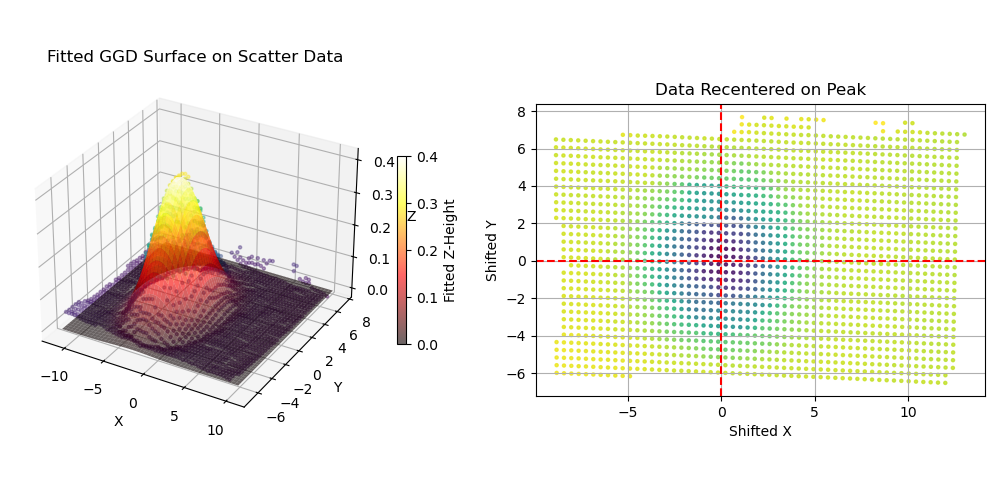

In [210]:
# --- 1. Prepare Data for Direct Fitting ---
frame = -1
corrected_points = X_corr_all[frame]
x_data = corrected_points[:, 0]
y_data = corrected_points[:, 1]
z_data = np.abs(corrected_points[:, 2])


# --- 2. Define the Generalized Gaussian Model for Fitting ---
def ggd_model(xy_data, A, x0, y0, sigma, p):
    x, y = xy_data
    term1 = (np.abs(x - x0) / sigma)**p
    term2 = (np.abs(y - y0) / sigma)**p
    return A * np.exp(-(term1 + term2))


# --- 3. Fit the Model Directly to the Scatter Data ---
# Combine x and y data for curve_fit
xy_data_for_fit = np.vstack((x_data, y_data))

# Define initial guesses and bounds based on the raw data
initial_guess = [np.max(z_data), np.mean(x_data), np.mean(y_data), 5, 2]
lower_bounds = [0, np.min(x_data), np.min(y_data), 0.1, 0.5]
upper_bounds = [10, np.max(x_data), np.max(y_data), 40, 5]

# Perform the curve fitting
params_fit, _ = curve_fit(
    ggd_model,
    xy_data_for_fit,
    z_data,
    p0=initial_guess,
    bounds=(lower_bounds, upper_bounds)
)

# Extract fitted parameters
A_fit, x0_fit, y0_fit, sigma_fit, p_fit = params_fit
print(f"Fitted Center (Peak): ({x0_fit:.2f}, {y0_fit:.2f})")


# --- 4. Recenter the Original Scatter Data ---
# Subtract the found peak center from the original high-resolution scatter data
points_recentered = corrected_points - [x0_fit, y0_fit, 0]


# --- 5. Visualize the Results ---
fig = plt.figure(figsize=(10, 5))

# Plot 1: The surface fit on the scatter data
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
# Plot the original scatter data
ax1.scatter(x_data, y_data, z_data, s=5, c=z_data, cmap='viridis', alpha=0.4, label='Original Points')

# Create a meshgrid to visualize the fitted surface
x_grid_range = np.linspace(x_data.min(), x_data.max(), 50)
y_grid_range = np.linspace(y_data.min(), y_data.max(), 50)
X_grid, Y_grid = np.meshgrid(x_grid_range, y_grid_range)
Z_fit = ggd_model(np.vstack((X_grid.ravel(), Y_grid.ravel())), *params_fit).reshape(50, 50)

# Plot the fitted GGD surface and capture its mappable object
surf_plot = ax1.plot_surface(X_grid, Y_grid, Z_fit, cmap='hot', edgecolor='none', alpha=0.6)
ax1.set_title("Fitted GGD Surface on Scatter Data")
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')

fig.colorbar(surf_plot, ax=ax1, shrink=0.4, label='Fitted Z-Height')

# Plot 2: The recentered scatter data
ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(points_recentered[:, 0], points_recentered[:, 1], s=5, alpha=0.8, c=points_recentered[:, 2], cmap='viridis')
ax2.axhline(0, color='r', linestyle='--')
ax2.axvline(0, color='r', linestyle='--')
ax2.set_title("Data Recentered on Peak")
ax2.set_xlabel('Shifted X'); ax2.set_ylabel('Shifted Y')
ax2.grid(True)
ax2.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

Starting GGD fit for each frame...
Processed 50/567 frames...
Processed 100/567 frames...
Processed 150/567 frames...
Processed 200/567 frames...
Processed 250/567 frames...
Processed 300/567 frames...
Processed 350/567 frames...
Processed 400/567 frames...
Processed 450/567 frames...
Processed 500/567 frames...
Processed 550/567 frames...
...Processing complete.


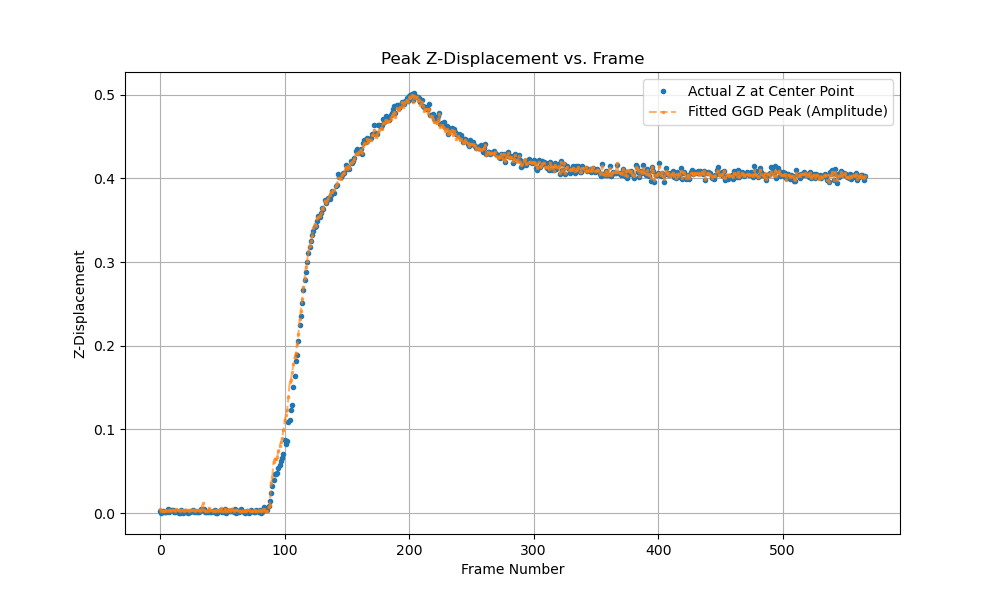

In [211]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- 1. Prepare Fixed Data and Initialize Results ---
# The XY data is the recentered data from the initial fit and is assumed constant.
xy_data_for_fit = np.vstack((points_recentered[:, 0], points_recentered[:, 1]))

# Find the index of the point closest to the center (0,0) to track its actual Z-value.
center_point_idx = np.argmin(np.linalg.norm(points_recentered[:, 0:2], axis=1))

# Lists to store the results from each frame
ggd_peak_displacements = []
actual_peak_displacements = []

print("Starting GGD fit for each frame...")

# --- 2. Loop Through All Frames and Fit GGD Model ---
for frame_idx in range(num_frames):
    # Get the Z-data for the current frame
    z_data = np.abs(X_corr_all[frame_idx][:, 2])
    
    # Get the actual Z-displacement of the center point for this frame
    actual_peak_z = z_data[center_point_idx]
    actual_peak_displacements.append(actual_peak_z)

    # Define initial guesses and bounds for the fitting
    # The center (x0, y0) is expected to be near (0,0) since the data is recentered.
    initial_guess = [np.max(z_data), 0, 0, 5, 2]
    lower_bounds = [0, -5, -5, 0.1, 0.5] # Allow center to vary slightly
    upper_bounds = [np.max(z_data) * 1.5, 5, 5, 40, 5]

    try:
        # Perform the curve fitting for the current frame
        params_fit, _ = curve_fit(
            ggd_model,
            xy_data_for_fit,
            z_data,
            p0=initial_guess,
            bounds=(lower_bounds, upper_bounds)
        )
        # The fitted amplitude 'A' is the peak of the GGD model
        A_fit = params_fit[0]
        ggd_peak_displacements.append(A_fit)

    except RuntimeError:
        # If the fit fails for a frame, append NaN and continue
        print(f"Warning: GGD fit failed for frame {frame_idx}. Appending NaN.")
        ggd_peak_displacements.append(np.nan)

    if (frame_idx + 1) % 50 == 0:
         print(f"Processed {frame_idx + 1}/{num_frames} frames...")

print("...Processing complete.")

# --- 3. Plot the Results ---
plt.figure(figsize=(10, 6))
plt.plot(range(num_frames), actual_peak_displacements, 'o', label='Actual Z at Center Point', markersize=3)
plt.plot(range(num_frames), ggd_peak_displacements, 's--', label='Fitted GGD Peak (Amplitude)', markersize=2,alpha=0.6)

plt.title('Peak Z-Displacement vs. Frame')
plt.xlabel('Frame Number')
plt.ylabel('Z-Displacement')
plt.legend()
plt.grid(True)
plt.show()